In [1]:
from Bio import SeqIO
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

ModuleNotFoundError: No module named 'Bio'

In [2]:
from Bio import SeqIO
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

ModuleNotFoundError: No module named 'Bio'

In [3]:
from Bio import SeqIO
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")


ModuleNotFoundError: No module named 'Bio'

In [4]:
%pip install biopython matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from Bio import SeqIO
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
fasta_file = "sequences.fasta"

sequences = {}

for record in SeqIO.parse(fasta_file, "fasta"):
    sequences[record.id] = str(record.seq).upper()

print(f"Loaded {len(sequences)} sequences.")

for sequence_id, sequence in sequences.items():
    print(f"{sequence_id}: {len(sequence)} bp")

Loaded 3 sequences.
sequence_001: 60 bp
sequence_002: 60 bp
sequence_003: 61 bp


In [3]:
def calculate_gc_content(sequence):
    """Calculate GC content as a percentage."""
    
    sequence = sequence.upper()
    
    g_count = sequence.count("G")
    c_count = sequence.count("C")
    
    gc_content = ((g_count + c_count) / len(sequence)) * 100
    
    return gc_content


def sliding_window_gc(sequence, window_size=10, step_size=5):
    """Calculate GC content across overlapping windows."""
    
    positions = []
    gc_values = []
    
    for start in range(0, len(sequence) - window_size + 1, step_size):
        
        end = start + window_size
        window = sequence[start:end]
        
        gc = calculate_gc_content(window)
        
        # Position at the center of the window
        position = start + (window_size // 2)
        
        positions.append(position)
        gc_values.append(gc)
    
    return positions, gc_values


print("Sliding-window GC functions created successfully!")

Sliding-window GC functions created successfully!


In [4]:
sequence_id = "sequence_001"
sequence = sequences[sequence_id]

positions, gc_values = sliding_window_gc(
    sequence,
    window_size=10,
    step_size=5
)

print("Sequence:", sequence_id)
print("Length:", len(sequence), "bp")
print()

for position, gc in zip(positions, gc_values):
    print(f"Position {position}: GC = {gc:.2f}%")

Sequence: sequence_001
Length: 60 bp

Position 5: GC = 50.00%
Position 10: GC = 40.00%
Position 15: GC = 50.00%
Position 20: GC = 60.00%
Position 25: GC = 60.00%
Position 30: GC = 50.00%
Position 35: GC = 40.00%
Position 40: GC = 50.00%
Position 45: GC = 50.00%
Position 50: GC = 50.00%
Position 55: GC = 60.00%


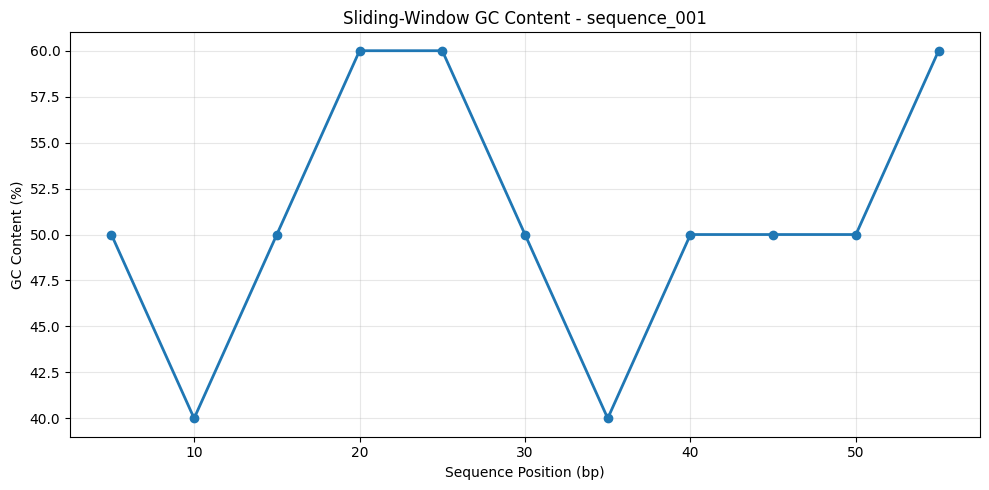

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(
    positions,
    gc_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Sequence Position (bp)")
plt.ylabel("GC Content (%)")

plt.title(
    f"Sliding-Window GC Content - {sequence_id}"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

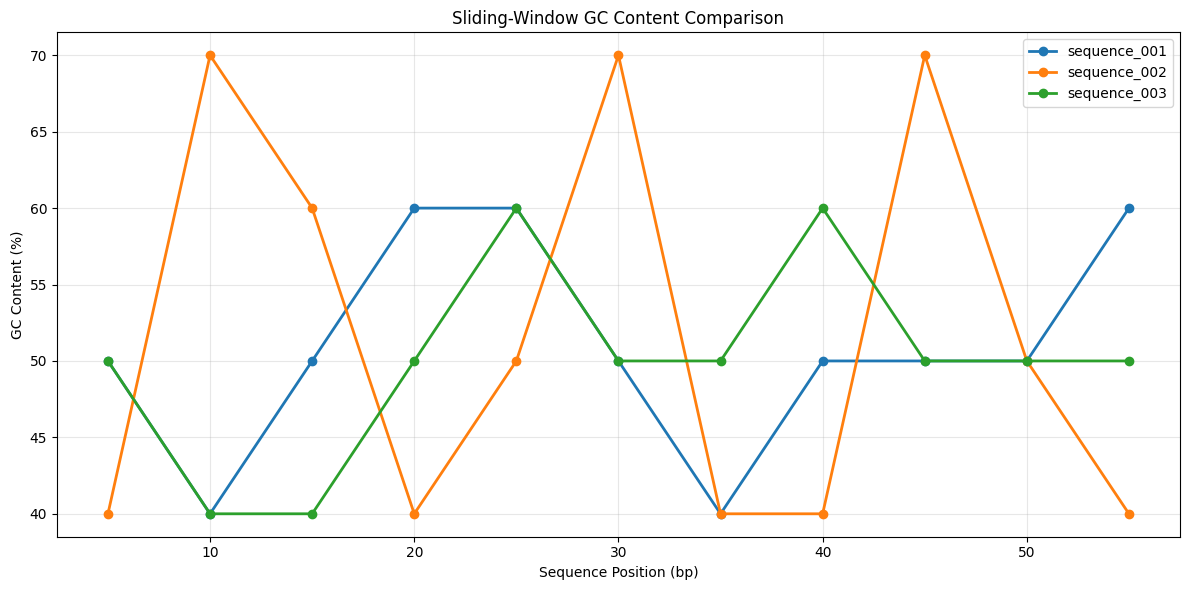

In [6]:
plt.figure(figsize=(12, 6))

for sequence_id, sequence in sequences.items():
    
    positions, gc_values = sliding_window_gc(
        sequence,
        window_size=10,
        step_size=5
    )
    
    plt.plot(
        positions,
        gc_values,
        marker="o",
        linewidth=2,
        label=sequence_id
    )

plt.xlabel("Sequence Position (bp)")
plt.ylabel("GC Content (%)")

plt.title("Sliding-Window GC Content Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

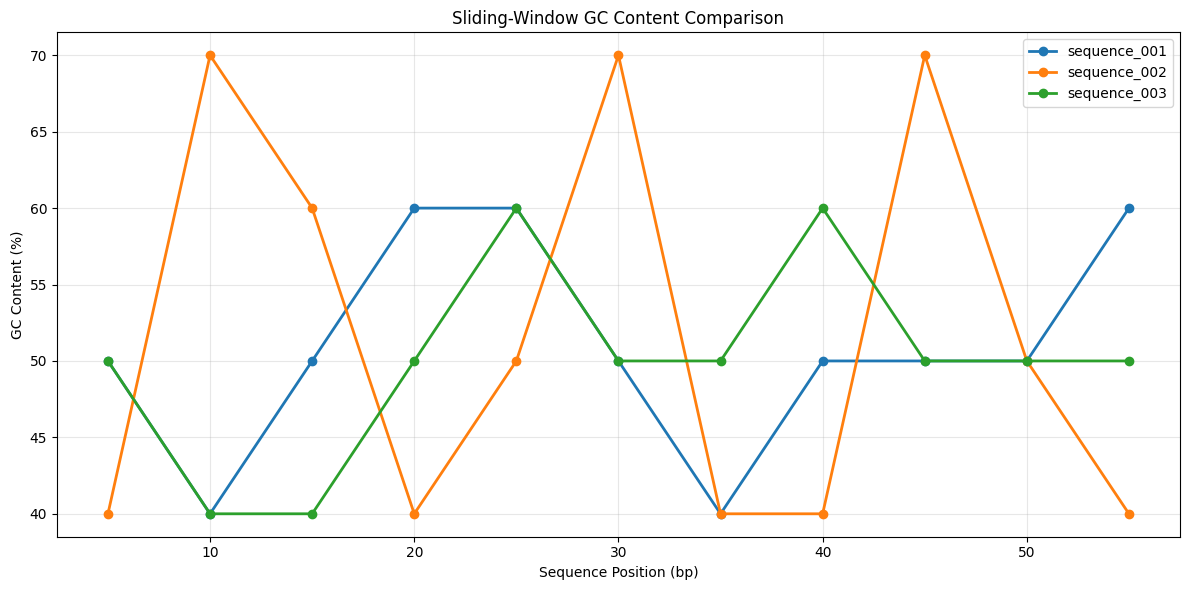

Figure saved successfully!


In [7]:
import os

# Create a folder for research figures
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(12, 6))

for sequence_id, sequence in sequences.items():

    positions, gc_values = sliding_window_gc(
        sequence,
        window_size=10,
        step_size=5
    )

    plt.plot(
        positions,
        gc_values,
        marker="o",
        linewidth=2,
        label=sequence_id
    )

plt.xlabel("Sequence Position (bp)")
plt.ylabel("GC Content (%)")
plt.title("Sliding-Window GC Content Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "figures/sliding_window_gc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully!")